# Library exploration

In [1]:
%load_ext autoreload
%autoreload 2

import networkx as nx

from cpid.io import AtomicCounterfactual, CausalExpression, CausalQuery
from cpid.lp import OrderFunctionalLPSolver
from cpid.signature import (
    PartialOrderSignature,
    SignatureQueryEvaluator,
    TotalOrderSignature,
)

import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.explain as gne

## IO

### AtomicCounterfactual

In [2]:
# Standard observational term
obs_term = AtomicCounterfactual(target_var="Y", target_val=1, interventions={})
assert obs_term.target_var == "Y"
assert obs_term.target_val == 1
assert obs_term.interventions == {}
print(obs_term)

# Standard interventional term
cf = AtomicCounterfactual(target_var="Y", target_val=1, interventions={"X": 1, "Z": 0})
assert cf.target_var == "Y"
assert cf.target_val == 1
assert cf.interventions == {"X": 1, "Z": 0}
print(cf)

# L2.5 Term
nested_cf = AtomicCounterfactual(
    target_var="Y", target_val=1, interventions={"X": {"Z": 0}}
)
assert nested_cf.target_var == "Y"
assert nested_cf.target_val == 1
assert nested_cf.interventions == {"X": {"Z": 0}}
assert nested_cf.is_nested()
print(nested_cf)

Y=1
Y_{X=1, Z=0}=1
Y_{X={'Z': 0}}=1


### CausalQuery and CausalExpression

In [3]:
q1 = CausalQuery(counterfactuals=[AtomicCounterfactual(target_var="Y", target_val=1)])
q2 = CausalQuery(counterfactuals=[AtomicCounterfactual(target_var="Y", target_val=0)])
q3 = CausalQuery(counterfactuals=[AtomicCounterfactual(target_var="Z", target_val=1)])
expr = q1 + q2
result = q3 - expr
assert isinstance(result, CausalExpression)
assert result.terms[q1] == -1.0
assert result.terms[q2] == -1.0
assert result.terms[q3] == 1.0

print(q1, q2, q3)
print(expr)
print(result)

P(Y=1) P(Y=0) P(Z=1)
+1 * P(Y=1) +1 * P(Y=0)
-1 * P(Y=1) -1 * P(Y=0) +1 * P(Z=1)


## Signature

### TotalOrderSignature

Good query is compatible with signature: True
Bad query is not compatible with signature: Signature is not compatible: requires a path W -> X but none exists in signature structure
Siganture space: 
[((0,), (0, 0), (0, 0, 0, 0)), ((0,), (0, 0), (0, 0, 0, 1)), ((0,), (0, 0), (0, 0, 1, 0)), ((0,), (0, 0), (0, 0, 1, 1)), ((0,), (0, 0), (0, 1, 0, 0))] 
... 
[((1,), (1, 1), (1, 0, 1, 1)), ((1,), (1, 1), (1, 1, 0, 0)), ((1,), (1, 1), (1, 1, 0, 1)), ((1,), (1, 1), (1, 1, 1, 0)), ((1,), (1, 1), (1, 1, 1, 1))]


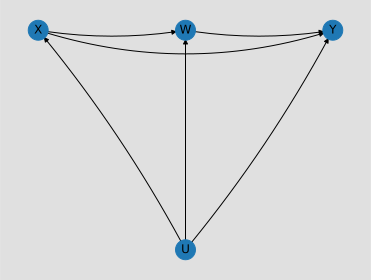

In [4]:
domains = {"X": 2, "W": 2, "Y": 2}
total_order = ["X", "W", "Y"]
sig = TotalOrderSignature(domains, total_order)

# ordered nodes and structure
assert sig.ordered_nodes == ["X", "W", "Y"]
assert sig.structure["X"] == []
assert sig.structure["W"] == ["X"]
assert sig.structure["Y"] == ["X", "W"]

# space size: X -> 2 funcs, W -> 2^(|parents|)=2^2=4 funcs, Y -> 2^(|parents|)=2^2^2=16 funcs => total 128
assert sig.size == 128

TotalOrderSignature.draw_canonical_pscm(sig)

good_query = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(target_var="Y", target_val=1, interventions={"X": 1})
    ]
)

print("Good query is compatible with signature:", sig.is_compatible(good_query))

bad_query = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(target_var="X", target_val=1, interventions={"W": 1})
    ]
)
try:
    sig.is_compatible(bad_query)
except ValueError as e:
    print("Bad query is not compatible with signature:", e)

print(f"Siganture space: \n{sig.space[:5]} \n... \n{sig.space[-5:]}")

### PartialOrderSignature

Query is (obviously) compatible with signature: True
However, signature has multiple valid topological orderings due to partial order structure.
[['Z', 'X', 'Y'], ['X', 'Z', 'Y']]
<module 'matplotlib.pyplot' from '/Users/eric.rossetto/Documents/Code/conservative_pid/.venv/lib/python3.14/site-packages/matplotlib/pyplot.py'>


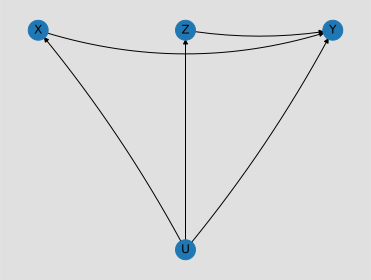

In [5]:
# small example: intervention on X, outcome Y
domains = {"X": 2, "Y": 2, "Z": 2}

q = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(
            target_var="Y", target_val=1, interventions={"X": 1, "Z": 0}
        )
    ],
    evidence={},
)

sig = PartialOrderSignature(domains, q)

# roots should include X
assert "X" in sig.ordered_nodes
# outcomes should include Y and come after roots
assert sig.ordered_nodes[-1] == "Y"
assert sig.structure["X"] == []
assert sig.structure["Y"] == ["X", "Z"] or sig.structure["Y"] == ["Z", "X"]

print("Query is (obviously) compatible with signature:", sig.is_compatible(q))
print(
    "However, signature has multiple valid topological orderings due to partial order structure."
)
print(list(nx.all_topological_sorts(sig.endogenous_structure())))

print(PartialOrderSignature.draw_canonical_pscm(sig))

## Signature and query evaluation

### TotalOrderSignature

In [6]:
domains = {"X": 2, "W": 2, "Y": 2}
total_order = ["X", "W", "Y"]
sig = TotalOrderSignature(domains, total_order)

p_y1_do_x1w1 = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(
            target_var="Y", target_val=1, interventions={"W": 1, "X": 1}
        )
    ],
    evidence={},
)

query_eval = SignatureQueryEvaluator(domains, sig, p_y1_do_x1w1)

# Consider row 19
print(f"Signature space size: {len(sig.space)}")
print("Signature space row 19:", sig.space[19])
print(f"Query evaluation for row 19: {query_eval.row_satisfies_query(sig.space[19])}")

Signature space size: 128
Signature space row 19: ((0,), (0, 1), (0, 0, 1, 1))
Query evaluation for row 19: True


### PartialOrderSignature

In [7]:
domains = {"X": 2, "W": 2, "Y": 2}
p_y1_do_x1w1 = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(
            target_var="Y", target_val=1, interventions={"W": 1, "X": 1}
        )
    ],
    evidence={},
)
sig = PartialOrderSignature(domains, p_y1_do_x1w1)
query_eval = SignatureQueryEvaluator(domains, sig, p_y1_do_x1w1)

print(f"Signature space size: {len(sig.space)}")
print("Signature space row 19:", sig.space[19])
print(f"Query evaluation for row 19: {query_eval.row_satisfies_query(sig.space[19])}")

Signature space size: 64
Signature space row 19: ((0,), (1,), (0, 0, 1, 1))
Query evaluation for row 19: True


## Linear Program with PuLP

### Generate some observational data using `pyagrum`

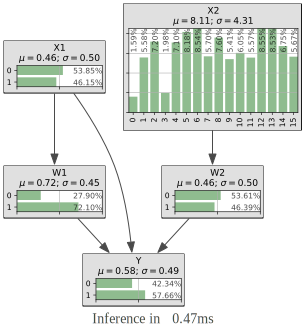

(None, None)

In [8]:
domains = {"X1": 2, "W1": 2, "Y": 2, "W2": 2, "X2": 16}
bn = gum.fastBN(
    f"X1[{domains['X1']}]->W1[{domains['W1']}]->Y[{domains['Y']}]; X1->Y; X2[{domains['X2']}]->W2[{domains['W2']}]->Y"
)
gum.initRandom(42)
bn.generateCPTs()

gum.initRandom(42)
df, _ = gum.generateSample(bn, 1000, show_progress=False)

gnb.showInference(bn), gne.showInformation(bn)

### Generate some observational data using `pgmpy`

### Generate the data using PPL

### Solving

In [10]:
l1_query = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(target_var="X1", target_val=0),
        AtomicCounterfactual(target_var="Y", target_val=1),
    ],
    evidence={"W1": 1},
)

l2_query = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(target_var="Y", target_val=1, interventions={"X1": 0})
    ],
    # evidence={"W1": 0},
)

l2_5_query = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(
            target_var="Y", target_val=1, interventions={"W1": {"X1": 0}}
        )
    ]
)

l3_query = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(target_var="Y", target_val=1, interventions={"X1": 1}),
        AtomicCounterfactual(target_var="Y", target_val=0, interventions={"X1": 0}),
    ]
)

lb_l1, ub_l1 = OrderFunctionalLPSolver(
    data=df,
    query=l1_query,
    solver_verbose=False,
)()

lb_l2, ub_l2 = OrderFunctionalLPSolver(
    data=df,
    query=l2_query,
    solver_verbose=False,
)()

lb_l2_5, ub_l2_5 = OrderFunctionalLPSolver(
    data=df,
    query=l2_5_query,
    solver_verbose=False,
)()

lb_l3, ub_l3 = OrderFunctionalLPSolver(
    data=df,
    query=l3_query,
    solver_verbose=False,
)()

print(f"\nL1 ({l1_query}) bounds: [{lb_l1}, {ub_l1}]")
print(f"L2 ({l2_query}) bounds: [{lb_l2}, {ub_l2}]")
print(f"L2.5 ({l2_5_query}) bounds: [{lb_l2_5}, {ub_l2_5}]")
print(f"L3 ({l3_query}) bounds: [{lb_l3}, {ub_l3}]")

Unnesting query P(X1=0, Y=1 | W1=1)
Generated 8 equivalence classes.
Detected conditional query. Applying Charnes-Cooper transformation.
Detected conditional query. Applying Charnes-Cooper transformation.
Unnesting query P(Y_{X1=0}=1)
Generated 6 equivalence classes.
Unnesting query P(Y_{W1={'X1': 0}}=1)
Generated 12 equivalence classes.
Unnesting query P(Y_{X1=1}=1, Y_{X1=0}=0)
Generated 6 equivalence classes.

L1 (P(X1=0, Y=1 | W1=1)) bounds: [0.23977433, 0.23977433]
L2 (P(Y_{X1=0}=1)) bounds: [0.296, 0.751]
L2.5 (P(Y_{W1={'X1': 0}}=1)) bounds: [0.29600000000000004, 0.7510000000000001]
L3 (P(Y_{X1=1}=1, Y_{X1=0}=0)) bounds: [0.0, 0.519]


In [19]:
nde = CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(
            target_var="Y", target_val=1, interventions={"X1": 0, "W1": {"X1": 1}}
        )
    ]
) - CausalQuery(
    counterfactuals=[
        AtomicCounterfactual(target_var="Y", interventions={"X1": 0}, target_val=1)
    ]
)

solver = OrderFunctionalLPSolver(
    data=df,
    query=nde,
    solver_verbose=False,
)

lb_nde, ub_nde = solver()
print(f"NDE bounds: [{lb_nde}, {ub_nde}]")

Unnesting term P(Y_{X1=0, W1={'X1': 1}}=1) with weight 1.0
Unnesting term P(Y_{X1=0}=1) with weight -1.0
Generated 20 equivalence classes.
NDE bounds: [-0.7510000000000001, 0.704]


In [20]:
solver.add_experimental_constraint(
    CausalQuery(
        counterfactuals=[
            AtomicCounterfactual(target_var="W1", target_val=1, interventions={"X1": 0})
        ]
    ),
    value=0.3,
)
solver.add_experimental_constraint(
    CausalQuery(
        counterfactuals=[
            AtomicCounterfactual(target_var="W1", target_val=1, interventions={"X1": 1})
        ]
    ),
    value=0.9,
)

Unnesting query P(W1_{X1=0}=1)
Unnesting query P(W1_{X1=1}=1)
